# Stap 1 — Leren van het verleden

**Project:** APEX hackathon, St. Aurora Medical Center, afdeling Interne Geneeskunde 4C  
**Notebook:** 01_stap1_leren_van_verleden  
**Auteur:** Sesmu  
**Datum:** september 2026

## Waar dit notebook toe dient

De afdeling wil elke ochtend weten hoeveel dagen de huidige patiënten nog zullen
liggen, om te kunnen plannen hoeveel bedden er vrijkomen. De nationale benchmark
(een verwachte ligduur per diagnose) blijkt daarvoor onbruikbaar: stays lopen
enkele dagen uit en de benchmark wordt in de praktijk niet meer gebruikt.

Voordat we iets kunnen voorspellen voor de huidige patiënten, moeten we leren
van patiënten uit het verleden. Van hen weten we twee dingen die we van de
huidige patiënten niet weten: hoe lang ze uiteindelijk lagen, en hoe ze
vertrokken. Dat maakt de historische data de enige bron waaruit we kunnen
afleiden welke kenmerken bij opname samenhangen met een korte of lange ligduur.

## Vragen die dit notebook beantwoordt

1. Staat de data goed in Python, en komt de omvang overeen met de documentatie?
2. Wat staat er in elke kolom, wat ontbreekt, en wat is bruikbaar als voorspeller?
3. Hoe is de ligduur verdeeld?
4. Hoe fout is de nationale benchmark: zit hij systematisch aan één kant (bias),
   of is hij willekeurig fout (spreiding)?
5. Welke kenmerken hangen samen met ligduur? Dit zijn de kandidaat-voorspellers
   voor het model in stap 3.

## Wat dit notebook niet doet

Er wordt hier nog geen model gebouwd en er wordt niets voorspeld voor de huidige
patiënten. Dat gebeurt in de volgende notebooks (stap 2 en 3). De huidige
patiënten worden alleen ingelezen om te controleren of de kolommen overeenkomen
met de historie.

## Data

| Tabel | Bestand | Inhoud |
|---|---|---|
| `hist` | patient_history.csv | 6825 afgesloten opnames, inclusief werkelijke ligduur en ontslagreden |
| `curr` | current_patients.csv | 32 patiënten die nu op de afdeling liggen |
| `diag` | diagnosis_lookup.csv | 36 ICD-10 codes met categorie, DBC-code en nationale benchmark |
| `staff` | staff_lookup.csv | 25 artsen met specialisme en jaren ervaring |

De opgeschoonde data komt uit `data_prep.ipynb` (collega). Dit notebook werkt
op de bestanden in de map `Data`.

In [67]:
# pandas is het pakket voor tabellen. De afkorting pd is de gewoonte;
# overal waar je straks pd. ziet, wordt pandas aangeroepen.
import pandas as pd

# pd.read_csv(pad) leest een CSV-bestand en geeft een DataFrame terug.
# Dat DataFrame slaan we op onder een korte naam, links van het =-teken.
#
# Het pad: dit notebook staat in de map Notebooks, de data staat in de map Data
# ernaast. ".." betekent "één map omhoog", dus ../Data/ = de map Data naast Notebooks.

hist = pd.read_csv("../Output/patient_history_prepared.csv")
#hist  = pd.read_csv("../Data/patient_history.csv")    # afgesloten opnames: hiervan kennen we de ligduur
curr  = pd.read_csv("../Data/current_patients.csv")   # patiënten die nu liggen: hiervoor gaan we straks voorspellen
diag  = pd.read_csv("../Data/diagnosis_lookup.csv")   # per ICD-code: categorie, DBC-code, nationale benchmark
staff = pd.read_csv("../Data/staff_lookup.csv")       # per arts: specialisme, jaren ervaring

# Geen uitvoer betekent: alle vier de bestanden zijn gevonden en gelezen.

In [68]:
curr.head()

,patient_id,age,sex,admission_date,days_admitted,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,systolic_bp,diastolic_bp,heart_rate,temperature,admission_notes,attending_physician_id,insurance_provider,room_number,bed_number,referred_by
0,PAT-C001,86,M,2025-01-13,7,E,K29.70,N17.9,NaN,118.0,87,107.0,NaN,Stable presentation. No immediate concerns on ...,PHY-09,CZ,4C-12,A,NaN
1,PAT-C002,70,F,2025-01-09,11,E,N39.0,I20.9; E11.65,25.5,129.0,70,63.0,38.5,Admitted following referral. Patient informed ...,PHY-22,Menzis,4C-13,A,Dr. Lars Visser
2,PAT-C003,60,M,2025-01-18,2,P,K57.30,A41.51,30.7,144.0,79,86.0,36.5,Settled on ward following admission. Patient c...,PHY-16,Menzis,4C-EB-05,—,Emergency Department
3,PAT-C004,75,F,2025-01-19,1,E,N39.0,E87.1,NaN,179.0,96,59.0,36.3,Ambulatory on admission. Presenting complaint ...,PHY-12,VGZ,4C-08,B,Smit
4,PAT-C005,44,M,2025-01-19,1,T,E11.9,NaN,30.7,106.0,90,59.0,38.1,Patient visibly unwell on transfer to ward. De...,PHY-01,ONVZ,4C-05,B,GP


In [69]:
# .shape geeft van een DataFrame (aantal rijen, aantal kolommen).
# We vergelijken met de documentatie op de slides.
# print() zet de uitkomst onder de cel; de tekst tussen aanhalingstekens is een label.

print("historie :", hist.shape)    # verwacht (6825, 21)
print("huidig   :", curr.shape)    # verwacht (32, 19)
print("diagnoses:", diag.shape)    # verwacht (36, 5)
print("staf     :", staff.shape)   # verwacht (25, 4)

historie : (6825, 37)
huidig   : (32, 19)
diagnoses: (36, 5)
staf     : (25, 4)


## Stap 1.2 — Begrijpen wat er in de kolommen staat

**Doel:** per kolom weten wat erin staat, van welk type het is en hoeveel er ontbreekt.

**Waarom:** een model kan alleen leren van kolommen die goed gevuld zijn en het
juiste type hebben. Een datum die als tekst is ingelezen kan niet worden
afgetrokken; een kolom die voor 40% leeg is vraagt een keuze (weglaten, invullen,
of "ontbreekt" zelf als informatie gebruiken). Dit is ook het moment om te
controleren of de inhoud klopt met wat de slides beloven.

In [70]:
# .head() toont de eerste 5 rijen van een tabel. Zo zie je concreet wat erin staat,
# in plaats van alleen kolomnamen. Dit is altijd de eerste blik op nieuwe data.
#
# Deze instelling zorgt dat pandas alle kolommen naast elkaar toont in plaats van
# een deel te verbergen achter "...".
pd.set_option("display.max_columns", None)

hist.head()

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,systolic_bp,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description,n_secondary,sec_cardiovascular,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory,adm_acute,dis_complicated,dis_to_facility,year
0,PAT-05580,50,F,2019-01-01,2019-01-08,7,T,N18.3,N17.9; A41.51,31.0,149.0,74.0,65.0,37.2,Patient admitted in stable condition. Alert an...,Discharge delayed on several occasions due to ...,PHY-10,CZ,4C-06,B,Recovered,Renal,4.9,"Chronic kidney disease, stage 3",2,0,0,1,0,0,0,1,0,0.0,1.0,1.0,2019
1,PAT-05526,60,F,2023-01-01,2023-01-06,5,E,G40.909,NaN,NaN,144.0,86.0,88.0,37.0,Patient admitted in stable condition. Alert an...,Uncomplicated admission. Responded well to tre...,PHY-14,VGZ,4C-02,B,Recovered,Neurological,4.2,"Epilepsy, unspecified, not intractable",0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,2023
2,PAT-01673,85,M,2018-01-02,2018-01-22,20,P,R65.20,I21.9; I20.9; G40.909,19.7,136.0,102.0,129.0,37.4,Patient in no acute distress on arrival. Vital...,Complex and extended stay. Patient required pe...,PHY-16,ONVZ,4C-01,A,Recovered,Infectious,9.4,Severe sepsis without septic shock,3,1,0,0,0,1,0,0,0,0.0,1.0,1.0,2018
3,PAT-01163,51,F,2012-01-03,2012-01-14,11,P,J18.9,E11.9,31.3,128.0,78.0,95.0,37.4,Admission requiring immediate stabilisation on...,Patient's recovery slower than anticipated. Fu...,PHY-21,VGZ,4C-08,A,Recovered,Respiratory,6.4,"Pneumonia, unspecified organism",1,0,0,0,1,0,0,0,0,1.0,1.0,0.0,2012
4,PAT-04550,69,M,2012-01-03,2012-01-09,6,P,J18.9,NaN,26.5,154.0,67.0,98.0,37.6,Patient in no acute distress on arrival. Vital...,Patient discharged home in good condition. All...,PHY-09,Zilveren Kruis,4C-06,A,Recovered,Respiratory,6.4,"Pneumonia, unspecified organism",0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,2012


In [71]:
# ===== Cel 3b | Stap 1.2 | Notities voluit lezen =====
# In de tabelweergave wordt lange tekst afgekapt. Om een notitie echt te lezen
# halen we hem eruit en printen we hem los.
# We gebruiken hier hist (niet df), omdat df pas in cel 9 wordt gemaakt.
#
# .iloc[i] pakt rij nummer i (tellen begint bij 0).

for i in [0, 1, 2]:
    print(f"--- Patiënt {hist['patient_id'].iloc[i]}, code {hist['primary_diagnosis_code'].iloc[i]}, ligduur {hist['actual_los'].iloc[i]} dagen")
    print("OPNAME :", hist["admission_notes"].iloc[i])
    print("ONTSLAG:", hist["discharge_notes"].iloc[i])
    print()

--- Patiënt PAT-05580, code N18.3, ligduur 7 dagen
OPNAME : Patient admitted in stable condition. Alert and oriented. Vitals within acceptable limits on arrival. History obtained directly from patient. Treatment plan initiated per admitting physician.
ONTSLAG: Discharge delayed on several occasions due to clinical instability. Eventual discharge to rehabilitation unit. Family extensively involved in planning. Community nursing support arranged.

--- Patiënt PAT-05526, code G40.909, ligduur 5 dagen
OPNAME : Patient admitted in stable condition. Alert and oriented. Vitals within acceptable limits on arrival. History obtained directly from patient. Treatment plan initiated per admitting physician.
ONTSLAG: Uncomplicated admission. Responded well to treatment from early in stay. Medications reconciled. GP letter sent. Self-management advice provided prior to discharge.

--- Patiënt PAT-01673, code R65.20, ligduur 20 dagen
OPNAME : Patient in no acute distress on arrival. Vital signs accept

In [72]:
# .info() geeft per kolom drie dingen:
#   - het type (Dtype): int64 = geheel getal, float64 = decimaal getal,
#     object = tekst. Datums moeten uiteindelijk datetime worden; dat zijn ze nu nog niet.
#   - Non-Null Count: hoeveel rijen een waarde hebben. Minder dan 6825 = er ontbreekt iets.
#   - het geheugengebruik (niet belangrijk voor ons).

hist.info()

<class 'pandas.DataFrame'>
RangeIndex: 6825 entries, 0 to 6824
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 6825 non-null   str    
 1   age                        6825 non-null   int64  
 2   sex                        6825 non-null   str    
 3   admission_date             6825 non-null   str    
 4   discharge_date             6825 non-null   str    
 5   actual_los                 6825 non-null   int64  
 6   adm_type                   6825 non-null   str    
 7   primary_diagnosis_code     6825 non-null   str    
 8   secondary_diagnosis_codes  4141 non-null   str    
 9   bmi                        4738 non-null   float64
 10  systolic_bp                6481 non-null   float64
 11  diastolic_bp               6464 non-null   float64
 12  heart_rate                 6504 non-null   float64
 13  temperature                5850 non-null   float64
 14  adm

In [73]:
# ===== Cel 5 | Stap 1.2 | Ontbrekend in hist (%) =====
# .isna() geeft per cel True als hij leeg is.
# .mean() over die True/False-waarden geeft het aandeel lege cellen per kolom.
# Vermenigvuldigen met 100 geeft procenten; .round(1) rondt af op één decimaal.
# .sort_values(ascending=False) zet de slechtst gevulde kolom bovenaan.

ontbrekend = (hist.isna().mean() * 100).round(1).sort_values(ascending=False)

# Alleen de kolommen tonen waar daadwerkelijk iets ontbreekt.
ontbrekend[ontbrekend > 0]

secondary_diagnosis_codes    39.3
bmi                          30.6
temperature                  14.3
dis_to_facility               6.7
dis_complicated               6.7
discharge_notes               6.7
diastolic_bp                  5.3
systolic_bp                   5.0
heart_rate                    4.7
adm_acute                     4.0
admission_notes               4.0
dtype: float64

In [74]:
# ===== Cel 6 | Stap 1.2 | Ontbrekend in curr (%) =====
# Dezelfde controle voor de huidige patiënten. Als een kolom bij hen veel vaker
# leeg is dan in de historie, kunnen we die straks niet gebruiken om voor hen
# te voorspellen, ook al leert het model er wel van.

ontbrekend_curr = (curr.isna().mean() * 100).round(1).sort_values(ascending=False)
ontbrekend_curr[ontbrekend_curr > 0]

secondary_diagnosis_codes    28.1
bmi                          28.1
referred_by                  12.5
temperature                  12.5
heart_rate                    6.2
admission_notes               3.1
systolic_bp                   3.1
dtype: float64

## Stap 1.3 — Datums omzetten en artsinformatie koppelen

De diagnose-informatie zit al in het opgeschoonde bestand (data_prep.ipynb).
Hier resteren twee dingen: de datums omzetten naar echte datums, en de
artstabel koppelen. Daarna controleren we of ontslag − opname gelijk is aan
`actual_los`.

In [75]:
# ===== Cel 7 | Stap 1.3 | Datums omzetten =====
# hist: datums zijn al uniform (JJJJ-MM-DD), maar staan nog als tekst.
# curr: datums staan in vier verschillende schrijfwijzen; format="mixed" laat pandas per rij raden.
hist["admission_date"] = pd.to_datetime(hist["admission_date"])
hist["discharge_date"] = pd.to_datetime(hist["discharge_date"])
curr["admission_date"] = pd.to_datetime(curr["admission_date"], format="mixed")

print(hist[["admission_date", "discharge_date"]].dtypes)   # verwacht: datetime64

admission_date    datetime64[us]
discharge_date    datetime64[us]
dtype: object


In [76]:
# ===== Cel 7b | Stap 1.3 | Controle datums huidige patiënten =====
# Opnamedatum + days_admitted moet voor iedereen op dezelfde "vandaag" uitkomen.
# Komt er één datum uit met 32 erachter, dan zijn alle datums goed geraden.
controle = curr[["patient_id", "admission_date", "days_admitted"]].copy()
controle["vandaag_afgeleid"] = controle["admission_date"] + pd.to_timedelta(controle["days_admitted"], unit="D")
print(controle["vandaag_afgeleid"].value_counts())

vandaag_afgeleid
2025-01-20    32
Name: count, dtype: int64


In [77]:
# ===== Cel 8 | Stap 1.3 | Controle datums vs actual_los =====
# Nu de datums echt datums zijn, kunnen we ze aftrekken. .dt.days geeft het aantal dagen.
ligduur_uit_datums = (hist["discharge_date"] - hist["admission_date"]).dt.days

# (a == b) geeft per rij True/False; .mean() is het aandeel True.
klopt = (ligduur_uit_datums == hist["actual_los"]).mean()
print(f"Aandeel patiënten waar ontslag − opname = actual_los: {klopt:.3f}")
print("Eerste opname:", hist["admission_date"].min().date())
print("Laatste opname:", hist["admission_date"].max().date())

Aandeel patiënten waar ontslag − opname = actual_los: 1.000
Eerste opname: 2012-01-01
Laatste opname: 2024-12-14


In [78]:
# ===== Cel 9 | Stap 1.3 | Koppelen aan staff =====
# .merge zoekt per patiënt het arts-id op in staff en plakt specialisme en ervaring ernaast.
#   how="left": houd alle patiënten, ook als een arts-id niet in staff staat.
# Het resultaat heet df: onze werktabel voor de rest van het notebook.
df = hist.merge(staff, left_on="attending_physician_id", right_on="physician_id", how="left")

print("Rijen voor koppeling:", len(hist), " na koppeling:", len(df))         # moet gelijk zijn
print("Patiënten zonder artsinformatie:", df["specialty"].isna().sum())        # hoop: 0
print("Patiënten zonder benchmark:", df["typical_los_benchmark"].isna().sum()) # controle op collega's koppeling

df[["patient_id", "diagnosis_description", "diagnosis_category", "typical_los_benchmark",
    "actual_los", "n_secondary", "specialty", "years_experience"]].head()

Rijen voor koppeling: 6825  na koppeling: 6825
Patiënten zonder artsinformatie: 0
Patiënten zonder benchmark: 0


,patient_id,diagnosis_description,diagnosis_category,typical_los_benchmark,actual_los,n_secondary,specialty,years_experience
0,PAT-05580,"Chronic kidney disease, stage 3",Renal,4.9,7,2,Pulmonology,6
1,PAT-05526,"Epilepsy, unspecified, not intractable",Neurological,4.2,5,0,Gastroenterology,19
2,PAT-01673,Severe sepsis without septic shock,Infectious,9.4,20,3,Nephrology,5
3,PAT-01163,"Pneumonia, unspecified organism",Respiratory,6.4,11,1,Internal Medicine,10
4,PAT-04550,"Pneumonia, unspecified organism",Respiratory,6.4,6,0,Cardiology,11


In [79]:
df.columns.tolist()

['patient_id',
 'age',
 'sex',
 'admission_date',
 'discharge_date',
 'actual_los',
 'adm_type',
 'primary_diagnosis_code',
 'secondary_diagnosis_codes',
 'bmi',
 'systolic_bp',
 'diastolic_bp',
 'heart_rate',
 'temperature',
 'admission_notes',
 'discharge_notes',
 'attending_physician_id',
 'insurance_provider',
 'room_number',
 'bed_number',
 'discharge_reason',
 'diagnosis_category',
 'typical_los_benchmark',
 'diagnosis_description',
 'n_secondary',
 'sec_cardiovascular',
 'sec_gastrointestinal',
 'sec_infectious',
 'sec_metabolic',
 'sec_neurological',
 'sec_other',
 'sec_renal',
 'sec_respiratory',
 'adm_acute',
 'dis_complicated',
 'dis_to_facility',
 'year',
 'physician_id',
 'name',
 'specialty',
 'years_experience']

## Stap 1.4 — De uitkomst: hoe is de ligduur verdeeld?

**Doel:** begrijpen hoe `actual_los` verdeeld is voordat we hem gaan voorspellen.

**Waarom:** een model voorspelt nooit beter dan de data toelaat. Als de ligduur
sterk scheef is (veel korte opnames, een lange staart), dan is het gemiddelde
misleidend en zijn uitschieters straks een aandachtspunt. En we willen weten of
de manier van vertrekken (hersteld, overgeplaatst, overleden) samenhangt met de
ligduur.

In [80]:
# ===== Cel 10 | Stap 1.4 | Samenvatting van de ligduur =====
# .describe() geeft in één keer: aantal, gemiddelde, spreiding (std), minimum,
# kwartielen (25%, 50% = mediaan, 75%) en maximum.
# Let vooral op het verschil tussen gemiddelde (mean) en mediaan (50%):
# als het gemiddelde hoger ligt, is de verdeling naar rechts scheef.
df["actual_los"].describe().round(1)

count    6825.0
mean        8.8
std         5.0
min         1.0
25%         5.0
50%         8.0
75%        11.0
max        89.0
Name: actual_los, dtype: float64

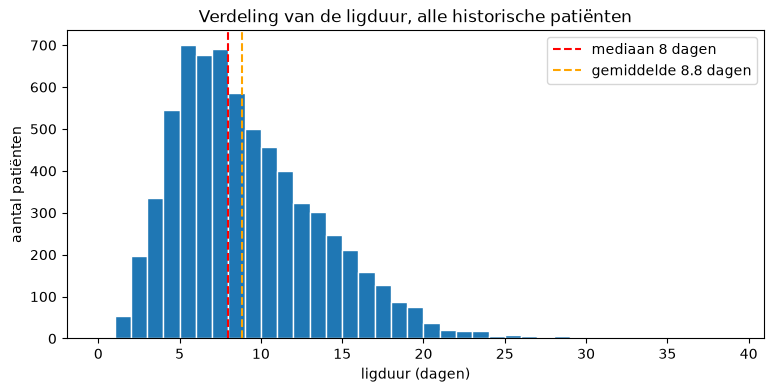

In [81]:
# ===== Cel 11 | Stap 1.4 | Histogram van de ligduur =====
# matplotlib is het pakket voor plaatjes; plt is de gebruikelijke afkorting.
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
# bins=range(0, 40): één staaf per dag, van 0 tot 40. Opnames langer dan 40 dagen
# vallen buiten beeld; die zijn er weinig en we tellen ze apart in cel 12.
plt.hist(df["actual_los"], bins=range(0, 40), edgecolor="white")
plt.axvline(df["actual_los"].median(), color="red", linestyle="--",
            label=f"mediaan {df['actual_los'].median():.0f} dagen")
plt.axvline(df["actual_los"].mean(), color="orange", linestyle="--",
            label=f"gemiddelde {df['actual_los'].mean():.1f} dagen")
plt.xlabel("ligduur (dagen)")
plt.ylabel("aantal patiënten")
plt.title("Verdeling van de ligduur, alle historische patiënten")
plt.legend()
plt.show()

In [82]:
# ===== Cel 12 | Stap 1.4 | Uitschieters =====
# Hoeveel opnames zijn extreem lang? Die kunnen een model op het verkeerde spoor zetten.
for grens in [20, 30, 40]:
    n = (df["actual_los"] > grens).sum()
    print(f"Langer dan {grens} dagen: {n} patiënten ({n/len(df)*100:.1f}%)")

Langer dan 20 dagen: 117 patiënten (1.7%)
Langer dan 30 dagen: 26 patiënten (0.4%)
Langer dan 40 dagen: 11 patiënten (0.2%)


In [83]:
# ===== Cel 13 | Stap 1.4 | Ligduur per ontslagreden =====
# .groupby("discharge_reason") splitst de tabel per ontslagreden.
# .agg() rekent per groep het aantal, gemiddelde en mediaan van de ligduur uit.
# Vraag: liggen overleden of overgeplaatste patiënten anders dan herstelde?
(df.groupby("discharge_reason")["actual_los"]
   .agg(aantal="size", gemiddelde="mean", mediaan="median")
   .round(1)
   .sort_values("aantal", ascending=False))

,aantal,gemiddelde,mediaan
discharge_reason,,,
Recovered,5916,8.7,8.0
Transferred,471,9.1,8.0
Deceased,232,11.0,10.5
AMA,206,8.9,7.0


## Stap 1.5 — Hoe fout is de nationale benchmark?

**Doel:** vaststellen of de benchmark systematisch fout is (bias) of willekeurig fout (spreiding).

**Waarom:** dit bepaalt de strategie. Systematische fout is met een correctie te
repareren (stap 2); willekeurige fout vraagt een model dat patiënten van elkaar
onderscheidt (stap 3). En het bepaalt hoe eerlijk "1 dag beter dan de benchmark"
straks is als lat.

Fout = werkelijke ligduur − benchmark. Positief = patiënt lag langer dan voorspeld.

In [84]:
# ===== Cel 14 | Stap 1.5 | Fout per patiënt, bias en MAE =====
# Nieuwe kolom in df: de fout van de benchmark voor deze patiënt.
df["fout_benchmark"] = df["actual_los"] - df["typical_los_benchmark"]

bias = df["fout_benchmark"].mean()          # gemiddelde MET teken: zit de benchmark aan één kant?
mae  = df["fout_benchmark"].abs().mean()    # gemiddelde ZONDER teken: hoeveel dagen ernaast, ongeacht richting

# Vergelijking: hoe slecht is de domste voorspelling, iedereen de mediaan (8 dagen)?
mediaan = df["actual_los"].median()
mae_mediaan = (df["actual_los"] - mediaan).abs().mean()

print(f"Bias van de benchmark : {bias:+.2f} dagen")
print(f"MAE  van de benchmark : {mae:.2f} dagen")
print(f"MAE  als iedereen {mediaan:.0f} dagen krijgt: {mae_mediaan:.2f} dagen")

Bias van de benchmark : +3.51 dagen
MAE  van de benchmark : 3.73 dagen
MAE  als iedereen 8 dagen krijgt: 3.64 dagen


In [85]:
# ===== Cel 14 | Stap 1.5 | Fout per patiënt, bias en MAE =====
# Nieuwe kolom in df: de fout van de benchmark voor deze patiënt.
df["fout_benchmark"] = df["actual_los"] - df["typical_los_benchmark"]

bias = df["fout_benchmark"].mean()          # gemiddelde MET teken: zit de benchmark aan één kant?
mae  = df["fout_benchmark"].abs().mean()    # gemiddelde ZONDER teken: hoeveel dagen ernaast, ongeacht richting

# Vergelijking: hoe slecht is de domste voorspelling, iedereen de mediaan (8 dagen)?
mediaan = df["actual_los"].median()
mae_mediaan = (df["actual_los"] - mediaan).abs().mean()

print(f"Bias van de benchmark : {bias:+.2f} dagen")
print(f"MAE  van de benchmark : {mae:.2f} dagen")
print(f"MAE  als iedereen {mediaan:.0f} dagen krijgt: {mae_mediaan:.2f} dagen")

Bias van de benchmark : +3.51 dagen
MAE  van de benchmark : 3.73 dagen
MAE  als iedereen 8 dagen krijgt: 3.64 dagen


In [86]:
# ===== Cel 15 | Stap 1.5 | Fout per diagnosecategorie =====
# Per categorie: aantal patiënten, bias, MAE, en gemiddelde benchmark vs werkelijk.
per_cat = (df.groupby("diagnosis_category")
             .agg(aantal=("fout_benchmark", "size"),
                  bias=("fout_benchmark", "mean"),
                  mae=("fout_benchmark", lambda x: x.abs().mean()),
                  benchmark=("typical_los_benchmark", "mean"),
                  werkelijk=("actual_los", "mean"))
             .round(2)
             .sort_values("bias", ascending=False))
per_cat

,aantal,bias,mae,benchmark,werkelijk
diagnosis_category,,,,,
Respiratory,1421,5.32,5.41,6.30,11.62
Infectious,640,4.60,4.86,10.08,14.68
Cardiovascular,1611,4.45,4.58,4.99,9.44
Neurological,400,4.11,4.30,4.76,8.87
Other,378,1.83,2.03,2.21,4.04
Renal,769,1.69,2.06,4.62,6.31
Metabolic,863,1.67,2.03,3.64,5.31
Gastrointestinal,743,1.60,1.98,4.72,6.32


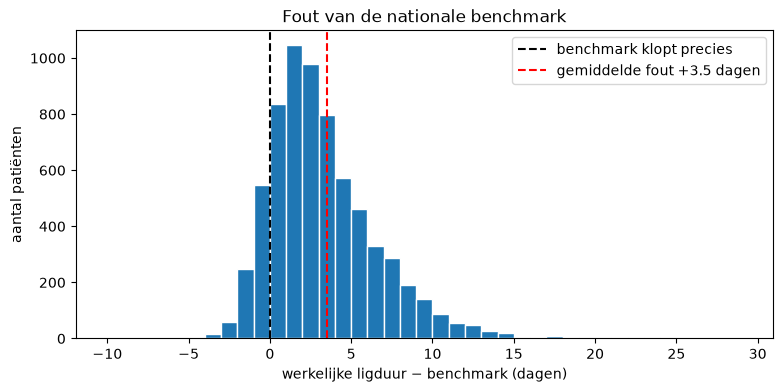

In [87]:
# ===== Cel 16 | Stap 1.5 | Histogram van de fout =====
plt.figure(figsize=(9, 4))
plt.hist(df["fout_benchmark"], bins=range(-10, 30), edgecolor="white")
plt.axvline(0, color="black", linestyle="--", label="benchmark klopt precies")
plt.axvline(bias, color="red", linestyle="--", label=f"gemiddelde fout {bias:+.1f} dagen")
plt.xlabel("werkelijke ligduur − benchmark (dagen)")
plt.ylabel("aantal patiënten")
plt.title("Fout van de nationale benchmark")
plt.legend()
plt.show()

In [88]:
# ===== Cel 16b | Stap 1.6 | Splitsen in train en test =====
# Vanaf hier kijken we alleen nog naar train. Test blijft dicht tot we een model
# beoordelen. Alles wat we uit de data leren (welke kenmerken, welke correctie,
# welk model) leren we op train; test is de eerlijke eindtoets.
#   test_size=0.2     : 20% van de patiënten naar test
#   random_state=42   : vaste loting, zodat iedereen dezelfde splitsing krijgt
# Elke patiënt staat één keer in df, dus splitsen op rij = splitsen op patiënt.
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
print("train:", train.shape, " test:", test.shape)

# Controle: liggen beide groepen gemiddeld even lang? Anders is de loting toevallig scheef.
print("gemiddelde ligduur train:", round(train["actual_los"].mean(), 2),
      " test:", round(test["actual_los"].mean(), 2))

train: (5460, 42)  test: (1365, 42)
gemiddelde ligduur train: 8.79  test: 9.01


In [89]:
# ===== Cel 16c | Stap 1.6 | Welke kolommen hebben we nu? =====
print(train.columns.tolist())

['patient_id', 'age', 'sex', 'admission_date', 'discharge_date', 'actual_los', 'adm_type', 'primary_diagnosis_code', 'secondary_diagnosis_codes', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'temperature', 'admission_notes', 'discharge_notes', 'attending_physician_id', 'insurance_provider', 'room_number', 'bed_number', 'discharge_reason', 'diagnosis_category', 'typical_los_benchmark', 'diagnosis_description', 'n_secondary', 'sec_cardiovascular', 'sec_gastrointestinal', 'sec_infectious', 'sec_metabolic', 'sec_neurological', 'sec_other', 'sec_renal', 'sec_respiratory', 'adm_acute', 'dis_complicated', 'dis_to_facility', 'year', 'physician_id', 'name', 'specialty', 'years_experience', 'fout_benchmark']


## Stap 1.6 — Welke kenmerken hangen samen met ligduur?

**Doel:** per opnamekenmerk kijken of de gemiddelde ligduur verschilt tussen groepen.

**Waarom:** dit is de lijst kandidaat-voorspellers voor het model. Alleen kenmerken
die bij opname bekend zijn komen in aanmerking. We kijken alleen op train, omdat
het kiezen van kenmerken een beslissing is die niet door de testset beïnvloed mag worden.

In [91]:
# ===== Cel 17 | Stap 1.6 | Ligduur per categorisch kenmerk (train) =====
for kolom in ["adm_type", "sex", "specialty", "insurance_provider"]:
    print(f"\n=== {kolom} ===")
    print(train.groupby(kolom)
               .agg(aantal=("actual_los", "size"),
                    ligduur=("actual_los", "mean"),
                    bias_benchmark=("fout_benchmark", "mean"))
               .round(2)
               .sort_values("ligduur", ascending=False))


=== adm_type ===
          aantal  ligduur  bias_benchmark
adm_type                                 
E           3343     9.16            3.83
T            539     8.73            3.38
P           1578     8.03            2.72

=== sex ===
     aantal  ligduur  bias_benchmark
sex                                 
M      2737     8.86            3.50
F      2723     8.72            3.42

=== specialty ===
                    aantal  ligduur  bias_benchmark
specialty                                          
Infectious Disease     214     9.34            3.79
Cardiology             660     8.98            3.62
Gastroenterology       232     8.95            3.36
Nephrology            1057     8.86            3.57
Pulmonology           1303     8.78            3.47
Internal Medicine     1994     8.62            3.32

=== insurance_provider ===
                    aantal  ligduur  bias_benchmark
insurance_provider                                 
CZ                    1176     8.90         

In [92]:
# ===== Cel 17b | Stap 1.6 | Bias van de benchmark per specialisme, gesorteerd =====
(train.groupby("specialty")
      .agg(aantal=("actual_los", "size"),
           ligduur=("actual_los", "mean"),
           bias_benchmark=("fout_benchmark", "mean"))
      .round(2)
      .sort_values("bias_benchmark"))

,aantal,ligduur,bias_benchmark
specialty,,,
Internal Medicine,1994,8.62,3.32
Gastroenterology,232,8.95,3.36
Pulmonology,1303,8.78,3.47
Nephrology,1057,8.86,3.57
Cardiology,660,8.98,3.62
Infectious Disease,214,9.34,3.79


In [93]:
# ===== Cel 17 | Stap 1.6 | Ligduur per categorisch kenmerk (train) =====
# Voor elk kenmerk met een beperkt aantal waarden: aantal patiënten, gemiddelde
# ligduur en bias van de benchmark per groep. display() toont elke tabel apart
# als opgemaakt kader.
from IPython.display import display

for kolom in ["adm_type", "sex", "specialty", "insurance_provider"]:
    print(f"=== {kolom} ===")
    display(train.groupby(kolom)
                 .agg(aantal=("actual_los", "size"),
                      ligduur=("actual_los", "mean"),
                      bias_benchmark=("fout_benchmark", "mean"))
                 .round(2)
                 .sort_values("ligduur", ascending=False))

=== adm_type ===


,aantal,ligduur,bias_benchmark
adm_type,,,
E,3343,9.16,3.83
T,539,8.73,3.38
P,1578,8.03,2.72


=== sex ===


,aantal,ligduur,bias_benchmark
sex,,,
M,2737,8.86,3.50
F,2723,8.72,3.42


=== specialty ===


,aantal,ligduur,bias_benchmark
specialty,,,
Infectious Disease,214,9.34,3.79
Cardiology,660,8.98,3.62
Gastroenterology,232,8.95,3.36
Nephrology,1057,8.86,3.57
Pulmonology,1303,8.78,3.47
Internal Medicine,1994,8.62,3.32


=== insurance_provider ===


,aantal,ligduur,bias_benchmark
insurance_provider,,,
CZ,1176,8.90,3.51
ONVZ,209,8.85,3.64
DSW,442,8.80,3.46
Menzis,876,8.79,3.47
Zilveren Kruis,1452,8.76,3.45
VGZ,1305,8.72,3.40


Voor de kandidatenlijst: opnametype is een echte voorspeller, een van de sterkere tot nu toe. En het is bij opname bekend, dus toegestaan.
Markdown-zin: Spoedopnames liggen ruim een dag langer dan geplande (9,2 vs 8,0) en de benchmark is bij spoed schever; 61% van de opnames is spoed. Opnametype gaat op de kandidatenlijst.


In [94]:
# ===== Cel 18 | Stap 1.6 | Leeftijd en nevendiagnoses (train) =====
train = train.copy()   # eigen kopie, zodat we kolommen mogen toevoegen zonder waarschuwing
train["leeftijdsgroep"] = pd.cut(train["age"], bins=[0, 50, 65, 75, 85, 120],
                                 labels=["<50", "50-64", "65-74", "75-84", "85+"])
print("=== leeftijd ===")
print(train.groupby("leeftijdsgroep", observed=True)["actual_los"]
           .agg(aantal="size", ligduur="mean").round(2))

print("\n=== aantal nevendiagnoses (n_secondary) ===")
print(train.groupby("n_secondary")["actual_los"]
           .agg(aantal="size", ligduur="mean").round(2))

print("\n=== acute opname (adm_acute, uit notitiesjabloon) ===")
print(train.groupby("adm_acute")["actual_los"]
           .agg(aantal="size", ligduur="mean").round(2))

=== leeftijd ===
                aantal  ligduur
leeftijdsgroep                 
<50               1003     7.80
50-64             1808     7.80
65-74             1255     9.08
75-84              823    10.36
85+                571    10.78

=== aantal nevendiagnoses (n_secondary) ===
             aantal  ligduur
n_secondary                 
0              2143     7.44
1              1911     8.92
2              1012    10.09
3               394    12.24

=== acute opname (adm_acute, uit notitiesjabloon) ===
           aantal  ligduur
adm_acute                 
0.0          2617     7.97
1.0          2628     9.62


In [95]:
# ===== Cel 19 | Stap 1.6 | De opnamenotities: sjablonen? (train) =====
print("Unieke opnamenotities:", train["admission_notes"].nunique())

pd.set_option("display.max_colwidth", 120)
(train.groupby("admission_notes")["actual_los"]
      .agg(aantal="size", ligduur="mean")
      .round(2)
      .sort_values("ligduur", ascending=False))

Unieke opnamenotities: 12


,aantal,ligduur
admission_notes,,
Admission requiring immediate stabilisation on arrival. Patient in significant discomfort. Analgesia administered per protocol. Next of kin present and informed. Urgent investigations requested.,434,9.92
Patient in evident distress on ward arrival. IV access established. Consultant notified and attending within the hour. Patient unable to fully cooperate with initial assessment.,397,9.76
Patient visibly unwell on transfer to ward. Detailed handover received from ED nursing staff. Safety concerns documented. Hourly observations initiated per protocol.,455,9.59
Patient admitted in distressed state. Urgent assessment performed on arrival. Immediate interventions initiated. Family notified of admission and current status. Close monitoring commenced.,462,9.53
High-acuity admission. Continuous monitoring commenced immediately. Senior physician review completed within 30 minutes of arrival. Escalation pathway discussed with team.,468,9.48
Complex presentation on admission. Unable to obtain complete history from patient; collateral obtained from accompanying family member. Specialist input anticipated from outset.,412,9.46
Stable presentation. No immediate concerns on admission review. Patient able to provide coherent history. Initial management plan in place. Awaiting results of investigations.,408,8.19
Patient in no acute distress on arrival. Vital signs acceptable. Baseline nursing assessment completed. Ward orientation provided to patient and accompanying family member.,467,8.15
Patient admitted in stable condition. Alert and oriented. Vitals within acceptable limits on arrival. History obtained directly from patient. Treatment plan initiated per admitting physician.,465,8.04


Twaalf sjablonen in twee groepen: "ziek bij binnenkomst" (ligduur ~9,6) en "stabiel bij binnenkomst" (~8,0). Binnen een groep geen verschil. adm_acute vat dit volledig samen; de losse sjablonen voegen niets toe. Er staat geen patiëntspecifieke informatie in de notities.

In [96]:
# ===== Cel 20 | Stap 1.6 | Getalsmatige kenmerken: correlatie met ligduur (train) =====
train["bmi_ontbreekt"] = train["bmi"].isna().astype(int)

getallen = ["age", "n_secondary", "adm_acute", "bmi", "bmi_ontbreekt",
            "systolic_bp", "diastolic_bp", "heart_rate", "temperature",
            "years_experience", "typical_los_benchmark",
            "sec_cardiovascular", "sec_respiratory", "sec_infectious", "sec_renal",
            "sec_metabolic", "sec_neurological", "sec_gastrointestinal", "sec_other"]
train[getallen + ["actual_los"]].corr()["actual_los"].drop("actual_los").round(3).sort_values()

years_experience        -0.012
heart_rate              -0.004
systolic_bp             -0.002
bmi                      0.001
diastolic_bp             0.002
temperature              0.012
bmi_ontbreekt            0.030
sec_neurological         0.053
sec_other                0.056
sec_respiratory          0.075
sec_metabolic            0.086
sec_gastrointestinal     0.103
sec_renal                0.110
sec_infectious           0.112
sec_cardiovascular       0.119
adm_acute                0.167
age                      0.218
n_secondary              0.277
typical_los_benchmark    0.613
Name: actual_los, dtype: float64

## Stap 2 — Benchmark corrigeren per categorie

**Doel:** de eenvoudigste verbetering van de benchmark meten: per diagnosecategorie
de gemiddelde afwijking erbij optellen.

**Waarom:** stap 1 liet zien dat de fout van de benchmark bijna volledig
systematisch is en per categorie verschilt. Deze correctie is de lat die het
model in stap 3 moet halen, en een verbetering die de afdeling morgen al kan
toepassen zonder software.

De correctiegetallen worden bepaald op train en beoordeeld op test.

In [97]:
# ===== Cel 21 | Stap 2 | Correctie per categorie bepalen op train =====
# Per categorie de gemiddelde fout van de benchmark op de trainset.
# Dit zijn de acht getallen die we bij de benchmark optellen.
correctie = train.groupby("diagnosis_category")["fout_benchmark"].mean().round(2)
print("Correctie per categorie (dagen erbij):")
print(correctie.sort_values(ascending=False))

Correctie per categorie (dagen erbij):
diagnosis_category
Respiratory         5.31
Cardiovascular      4.45
Infectious          4.45
Neurological        4.16
Other               1.87
Renal               1.65
Gastrointestinal    1.56
Metabolic           1.55
Name: fout_benchmark, dtype: float64


In [98]:
# ===== Cel 22 | Stap 2 | Correctie toepassen en beoordelen op test =====
# .map(correctie) zoekt voor elke testpatiënt het correctiegetal van zijn categorie op.
test = test.copy()
test["benchmark_gecorrigeerd"] = test["typical_los_benchmark"] + test["diagnosis_category"].map(correctie)

# Drie voorspellingen naast elkaar, alle drie beoordeeld op dezelfde testpatiënten.
# De mediaan komt uit train (test mag niet meepraten).
mae_benchmark    = (test["actual_los"] - test["typical_los_benchmark"]).abs().mean()
mae_mediaan      = (test["actual_los"] - train["actual_los"].median()).abs().mean()
mae_gecorrigeerd = (test["actual_los"] - test["benchmark_gecorrigeerd"]).abs().mean()

print(f"MAE benchmark (origineel)       : {mae_benchmark:.2f} dagen")
print(f"MAE iedereen de mediaan         : {mae_mediaan:.2f} dagen")
print(f"MAE benchmark + correctie       : {mae_gecorrigeerd:.2f} dagen")
print(f"Winst t.o.v. originele benchmark: {mae_benchmark - mae_gecorrigeerd:.2f} dagen "
      f"({(mae_benchmark - mae_gecorrigeerd) / mae_benchmark * 100:.0f}%)")

MAE benchmark (origineel)       : 3.88 dagen
MAE iedereen de mediaan         : 3.73 dagen
MAE benchmark + correctie       : 2.44 dagen
Winst t.o.v. originele benchmark: 1.43 dagen (37%)


Dit is het eerste harde resultaat van de hackathon, netjes gemeten op patiënten die niet hebben meegedaan aan het bepalen van de correctie:
Benchmark origineel: 3,88
Iedereen 8 dagen: 3,73 (nog steeds beter dan de benchmark)
Benchmark + correctie per categorie: 2,44
Winst: 1,43 dag, 37%
De opdracht vroeg 1 dag óf 20%. De correctie haalt beide, ruim. Zonder model, zonder software, met acht getallen op een briefje.
De getallen op test liggen iets hoger dan op alle data (3,88 vs 3,73) omdat de testset toevallig wat langere ligduren heeft (9,01 vs 8,79, zag je bij cel 16b). Dat is normaal en juist de reden waarom je op test meet: het is het eerlijke getal.
Wat je hiermee zegt:
Met een correctie per diagnosecategorie daalt de fout van 3,9 naar 2,4 dagen (−37%). Dat is al ruim boven de gevraagde verbetering van 1 dag of 20%, en het is een oplossing die de afdeling direct kan toepassen. De resterende 2,4 dag is spreiding tussen patiënten met dezelfde diagnose; daarop richt het model in stap 3 zich.
Wat het model in stap 3 moet doen: onder 2,44 komen. Dat is de lat, niet de 3,88.


In [100]:
# ===== Cel 23 | Stap 2 | Is de gecorrigeerde benchmark nog scheef? =====
# Na correctie hoort de bias op test rond nul te liggen. Wat overblijft is spreiding:
# patiënten met dezelfde diagnose die toch verschillend lang liggen.
test["fout_gecorrigeerd"] = test["actual_los"] - test["benchmark_gecorrigeerd"]
print(f"Bias na correctie: {test['fout_gecorrigeerd'].mean():+.2f} dagen (hoort ~0 te zijn)")
print(f"MAE  na correctie: {test['fout_gecorrigeerd'].abs().mean():.2f} dagen (dit moet het model verslaan)")

Bias na correctie: +0.17 dagen (hoort ~0 te zijn)
MAE  na correctie: 2.44 dagen (dit moet het model verslaan)


Na correctie per categorie is de bias op test +0,2 dag (was +3,5) en de MAE 2,44 dag (was 3,88). De benchmark is nu recht gezet; de resterende fout is spreiding tussen patiënten binnen een diagnose. Het model in stap 3 moet onder 2,44 komen om iets toe te voegen.we hebben nu 